
# Exploratory Data Analysis (EDA) with Python

## Learning objectives

By the end of this notebook, students should be able to:

- inspect a dataset and identify each variable's data type,
- distinguish numerical and categorical variables,
- detect missing values and evaluate their importance,
- perform univariate and bivariate analysis,
- identify potential outliers using statistical and visual methods,
- summarize EDA findings, and
- recommend appropriate preprocessing steps before modeling.

---

### Tools used

This notebook uses:

- `pandas` for data manipulation,
- `numpy` for numerical operations, and
- `matplotlib` for visualization.

The examples use a deliberately imperfect sample dataset containing:

- numeric variables,
- categorical variables,
- missing values,
- inconsistent category labels, and
- potential outliers.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")



## 1. Create a sample dataset

For teaching purposes, we will create a small customer dataset.

The dataset contains:

| Variable | Meaning |
|---|---|
| `customer_id` | Customer identifier |
| `age` | Customer age |
| `monthly_income` | Monthly income |
| `spending_score` | Spending score from 0–100 |
| `years_as_customer` | Number of years as a customer |
| `gender` | Customer gender |
| `city` | Customer city |
| `membership` | Membership level |
| `purchased` | Whether the customer purchased a product |

Some values are intentionally missing or unusual so that we can practice EDA.


In [2]:

rng = np.random.default_rng(42)
n = 120

df = pd.DataFrame({
    "customer_id": np.arange(1001, 1001 + n),
    "age": rng.normal(35, 10, n).round(),
    "monthly_income": rng.normal(8_000_000, 2_500_000, n).round(-3),
    "spending_score": np.clip(rng.normal(60, 18, n), 0, 100).round(),
    "years_as_customer": np.clip(rng.normal(4, 2.5, n), 0, None).round(1),
    "gender": rng.choice(["Male", "Female"], n, p=[0.48, 0.52]),
    "city": rng.choice(["Surabaya", "Jakarta", "Bandung", "Malang"], n),
    "membership": rng.choice(["Basic", "Silver", "Gold"], n, p=[0.45, 0.35, 0.20]),
})

# Create a target-like variable for bivariate examples
purchase_probability = (
    0.15
    + 0.003 * df["spending_score"]
    + 0.06 * (df["membership"] == "Gold").astype(int)
    + 0.04 * (df["monthly_income"] > 9_000_000).astype(int)
)

df["purchased"] = np.where(
    rng.random(n) < purchase_probability.clip(0, 0.95),
    "Yes",
    "No"
)

# Add missing values
for col, count in {
    "age": 5,
    "monthly_income": 7,
    "gender": 3,
    "city": 4,
    "membership": 2,
}.items():
    idx = rng.choice(df.index, count, replace=False)
    df.loc[idx, col] = np.nan

# Add inconsistent category labels
df.loc[rng.choice(df.index, 2, replace=False), "city"] = "surabaya"
df.loc[rng.choice(df.index, 2, replace=False), "gender"] = "female "

# Add potential outliers
df.loc[3, "age"] = 95
df.loc[10, "monthly_income"] = 35_000_000
df.loc[55, "monthly_income"] = 42_000_000
df.loc[80, "years_as_customer"] = 25

df.head()


,customer_id,age,monthly_income,spending_score,years_as_customer,gender,city,membership,purchased
0,1001,38.00,"5,441,000.00",44.00,3.60,Female,Jakarta,Basic,No
1,1002,25.00,"8,448,000.00",58.00,5.00,Female,Surabaya,Basic,No
2,1003,43.00,"8,550,000.00",28.00,6.50,Female,Bandung,Basic,No
3,1004,95.00,"11,398,000.00",34.00,1.40,Female,NaN,Basic,No
4,1005,15.00,"10,088,000.00",98.00,3.70,Female,Malang,Silver,No



# 2. First look at the data

EDA should begin with simple questions:

1. How many rows and columns are there?
2. What do the first few records look like?
3. Are the column names understandable?
4. What data types did pandas infer?
5. Are there obviously impossible or suspicious values?


In [3]:

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())
display(df.sample(5, random_state=1))


Dataset shape: (120, 9)

Column names:
['customer_id', 'age', 'monthly_income', 'spending_score', 'years_as_customer', 'gender', 'city', 'membership', 'purchased']


,customer_id,age,monthly_income,spending_score,years_as_customer,gender,city,membership,purchased
0,1001,38.00,"5,441,000.00",44.00,3.60,Female,Jakarta,Basic,No
1,1002,25.00,"8,448,000.00",58.00,5.00,Female,Surabaya,Basic,No
2,1003,43.00,"8,550,000.00",28.00,6.50,Female,Bandung,Basic,No
3,1004,95.00,"11,398,000.00",34.00,1.40,Female,NaN,Basic,No
4,1005,15.00,"10,088,000.00",98.00,3.70,Female,Malang,Silver,No


,customer_id,age,monthly_income,spending_score,years_as_customer,gender,city,membership,purchased
95,1096,21.00,"10,507,000.00",38.00,4.40,Male,Malang,Basic,No
54,1055,30.00,NaN,56.00,3.30,Female,Jakarta,Basic,No
59,1060,45.00,NaN,66.00,7.40,Female,Bandung,Basic,No
117,1118,35.00,"7,593,000.00",65.00,1.10,Female,Jakarta,Basic,Yes
77,1078,37.00,"7,013,000.00",47.00,1.30,Female,Jakarta,Basic,No



## 3. Analyze data types

A variable's **storage type** is not always the same as its **analytical type**.

For example:

- `customer_id` is stored as an integer but behaves like an identifier.
- `membership` is stored as text but represents an ordered category.
- `purchased` is stored as text but represents a binary categorical variable.

Common analytical data types include:

- **Numerical**
  - continuous: income, temperature, height
  - discrete: number of purchases, number of children
- **Categorical**
  - nominal: city, gender, product type
  - ordinal: satisfaction level, membership tier
- **Datetime**
- **Identifier**


In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        120 non-null    int64  
 1   age                115 non-null    float64
 2   monthly_income     113 non-null    float64
 3   spending_score     120 non-null    float64
 4   years_as_customer  120 non-null    float64
 5   gender             117 non-null    object 
 6   city               116 non-null    object 
 7   membership         118 non-null    object 
 8   purchased          120 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 8.6+ KB


In [5]:

dtype_summary = pd.DataFrame({
    "pandas_dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "missing": df.isna().sum()
})

dtype_summary


,pandas_dtype,n_unique,missing
customer_id,int64,120,0
age,float64,35,5
monthly_income,float64,112,7
spending_score,float64,57,0
years_as_customer,float64,65,0
gender,object,3,3
city,object,5,4
membership,object,3,2
purchased,object,2,0



### Analytical interpretation

A good EDA does not blindly trust inferred data types.

For this dataset:

- `customer_id` → identifier
- `age`, `monthly_income`, `spending_score`, `years_as_customer` → numerical
- `gender`, `city`, `membership`, `purchased` → categorical

This distinction matters because different variable types require different summaries and preprocessing methods.


In [6]:

identifier_cols = ["customer_id"]

numeric_cols = [
    "age",
    "monthly_income",
    "spending_score",
    "years_as_customer"
]

categorical_cols = [
    "gender",
    "city",
    "membership",
    "purchased"
]

print("Identifier columns :", identifier_cols)
print("Numerical columns  :", numeric_cols)
print("Categorical columns:", categorical_cols)


Identifier columns : ['customer_id']
Numerical columns  : ['age', 'monthly_income', 'spending_score', 'years_as_customer']
Categorical columns: ['gender', 'city', 'membership', 'purchased']



# 4. Find categorical data

A quick automatic method is to inspect columns with `object`, `category`, or `bool` data types.

However, domain knowledge is still important because integer columns may sometimes represent categories.


In [7]:

auto_categorical = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
auto_numeric = df.select_dtypes(include=np.number).columns.tolist()

print("Automatically detected categorical columns:")
print(auto_categorical)

print("\nAutomatically detected numerical columns:")
print(auto_numeric)


Automatically detected categorical columns:
['gender', 'city', 'membership', 'purchased']

Automatically detected numerical columns:
['customer_id', 'age', 'monthly_income', 'spending_score', 'years_as_customer']



## Inspect category values

Always inspect the actual category labels.

This often reveals:

- spelling differences,
- unwanted spaces,
- inconsistent capitalization,
- unexpected values, and
- rare categories.


In [8]:

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- gender ---
gender
Female     66
Male       49
NaN         3
female      2
Name: count, dtype: int64

--- city ---
city
Malang      32
Jakarta     29
Bandung     29
Surabaya    24
NaN          4
surabaya     2
Name: count, dtype: int64

--- membership ---
membership
Basic     62
Silver    37
Gold      19
NaN        2
Name: count, dtype: int64

--- purchased ---
purchased
No     79
Yes    41
Name: count, dtype: int64



### Observation

You should notice that some categories are inconsistent:

- `Surabaya` and `surabaya`
- `Female` and `female `

These are logically the same category but would be treated as different values by most algorithms.



# 5. Missing-value analysis

Missing values are common in real datasets.

Important questions include:

- Which columns contain missing values?
- How many values are missing?
- What percentage of each column is missing?
- Is the missingness likely random?
- Should we drop rows, drop columns, or impute values?


In [9]:

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary.sort_values("missing_percent", ascending=False)


,missing_count,missing_percent
monthly_income,7,5.83
age,5,4.17
city,4,3.33
gender,3,2.50
membership,2,1.67


In [10]:

missing_by_row = df.isna().sum(axis=1)

print("Rows with at least one missing value:", (missing_by_row > 0).sum())
print("Maximum missing values in a single row:", missing_by_row.max())


Rows with at least one missing value: 21
Maximum missing values in a single row: 1



## Visualize missingness by column


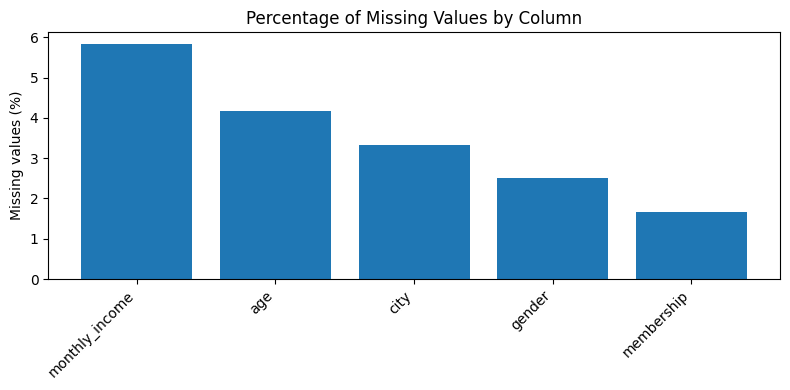

In [11]:

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 4))
plt.bar(missing_pct.index, missing_pct.values)
plt.ylabel("Missing values (%)")
plt.title("Percentage of Missing Values by Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



### Missing-value interpretation

There is no universal rule saying that every missing value should be removed.

Typical options:

- **Numerical variable**
  - median imputation: robust when outliers are present
  - mean imputation: reasonable for roughly symmetric distributions
  - model-based imputation: useful in more advanced settings
- **Categorical variable**
  - most frequent category
  - explicit `"Unknown"` category
- **Drop rows**
  - appropriate when only a tiny number of observations are missing and data loss is acceptable
- **Drop a feature**
  - considered when a feature has very high missingness and little analytical value

The reason for missingness should be investigated whenever possible.



# 6. Univariate analysis

Before examining relationships between variables, understand each variable individually.

For numerical variables, common summaries are:

- count
- mean
- median
- standard deviation
- minimum and maximum
- quartiles
- distribution shape

For categorical variables, inspect:

- number of categories
- frequency
- percentage
- imbalance


In [12]:

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,115.00,34.77,9.66,15.00,29.50,35.00,40.00,95.00
monthly_income,113.00,"8,436,752.21","4,766,916.09","2,632,000.00","5,968,000.00","7,648,000.00","9,608,000.00","42,000,000.00"
spending_score,120.00,61.08,18.20,14.00,49.75,62.00,73.25,100.00
years_as_customer,120.00,4.21,3.09,0.00,2.27,4.15,5.83,25.00


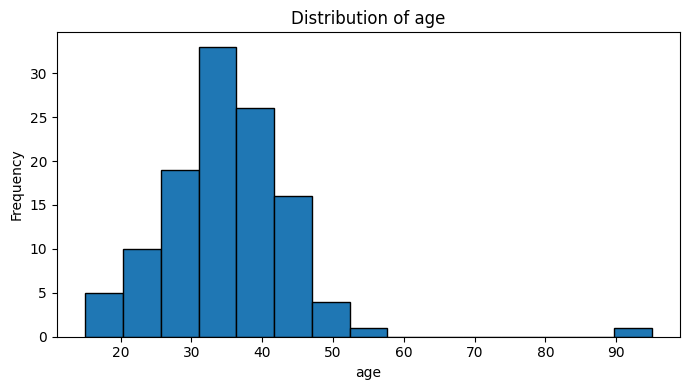

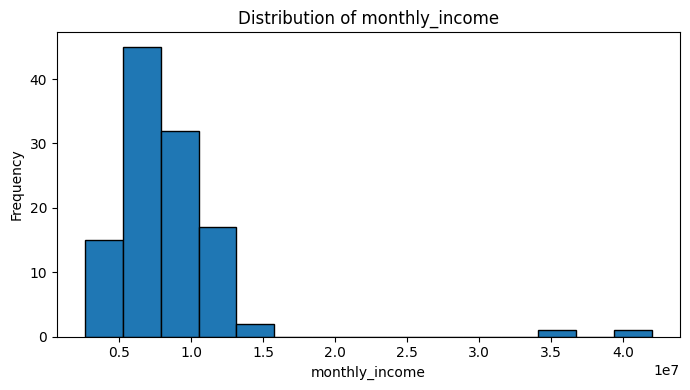

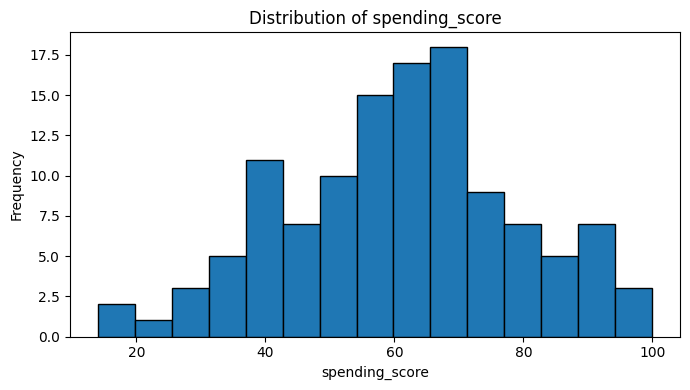

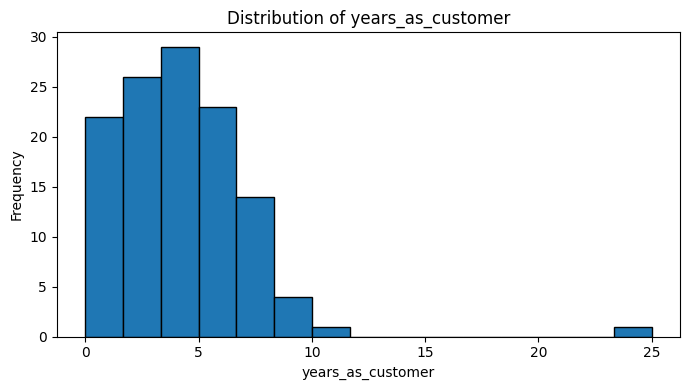

In [13]:

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=15, edgecolor="black")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


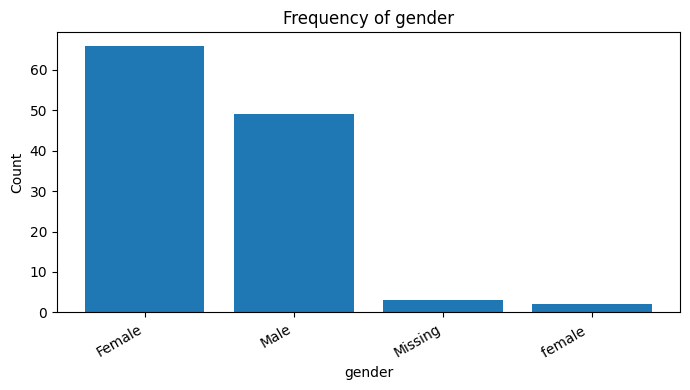

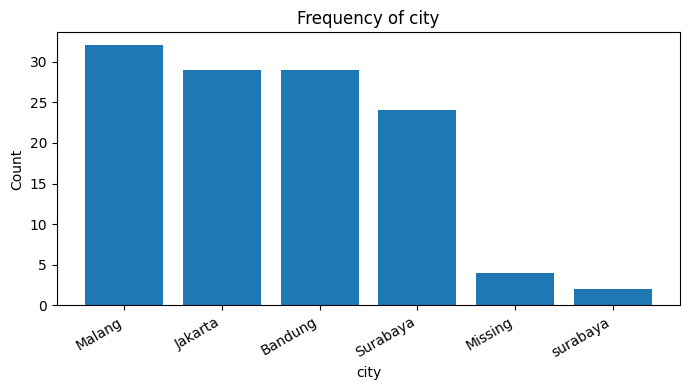

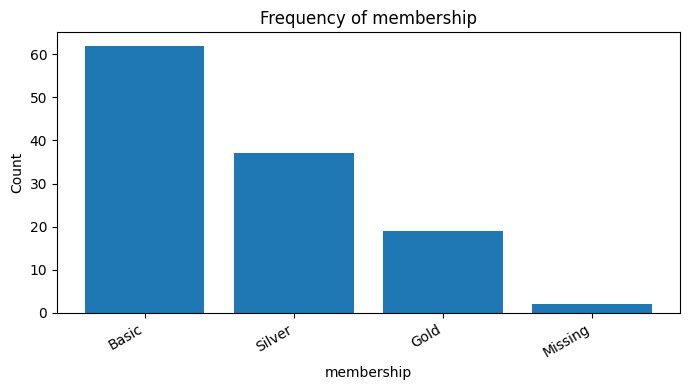

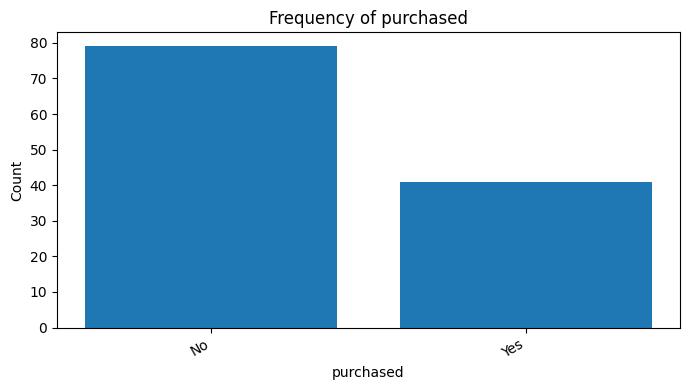

In [14]:

for col in categorical_cols:
    counts = df[col].fillna("Missing").value_counts()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Frequency of {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()



# 7. Bivariate analysis

**Bivariate analysis** investigates the relationship between two variables.

The appropriate method depends on the variable types.

| Variable A | Variable B | Useful techniques |
|---|---|---|
| Numerical | Numerical | correlation, scatter plot |
| Numerical | Categorical | group statistics, box plot |
| Categorical | Categorical | crosstab, proportions |


## 7.1 Numerical vs numerical

In [15]:

correlation_matrix = df[numeric_cols].corr(numeric_only=True)
correlation_matrix


,age,monthly_income,spending_score,years_as_customer
age,1.00,-0.01,-0.23,-0.10
monthly_income,-0.01,1.00,-0.03,0.01
spending_score,-0.23,-0.03,1.00,-0.03
years_as_customer,-0.10,0.01,-0.03,1.00


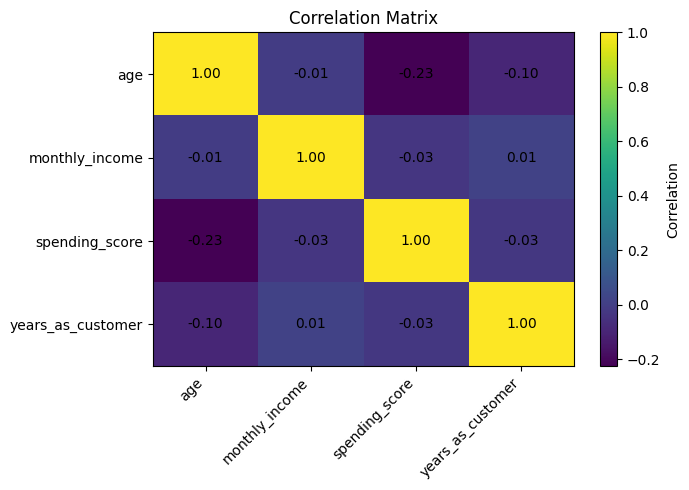

In [16]:

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


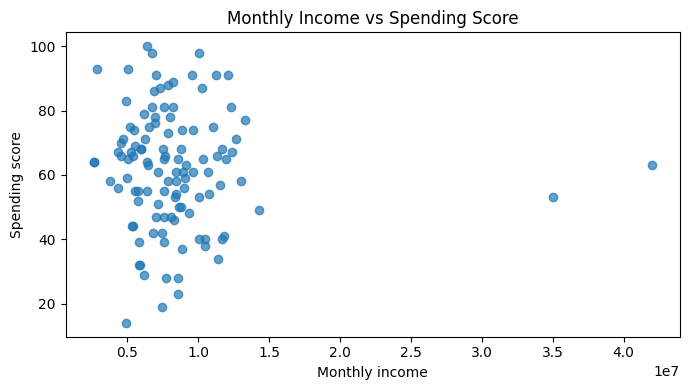

In [17]:

plt.figure(figsize=(7, 4))
plt.scatter(df["monthly_income"], df["spending_score"], alpha=0.7)
plt.xlabel("Monthly income")
plt.ylabel("Spending score")
plt.title("Monthly Income vs Spending Score")
plt.tight_layout()
plt.show()



### Important note about correlation

Correlation measures association, not causation.

Also remember:

- Pearson correlation mainly captures **linear** relationships.
- A correlation close to zero does not guarantee that no relationship exists.
- Outliers can strongly affect correlation values.


## 7.2 Numerical vs categorical

In [18]:

df.groupby("membership", dropna=False)["monthly_income"].agg(
    ["count", "mean", "median", "std"]
)


,count,mean,median,std
membership,,,,
Basic,58,"8,055,172.41","7,304,500.00","5,185,582.36"
Gold,19,"8,198,526.32","7,878,000.00","2,171,566.62"
Silver,34,"9,236,500.00","8,342,000.00","5,208,457.24"
NaN,2,"8,170,000.00","8,170,000.00","875,398.20"


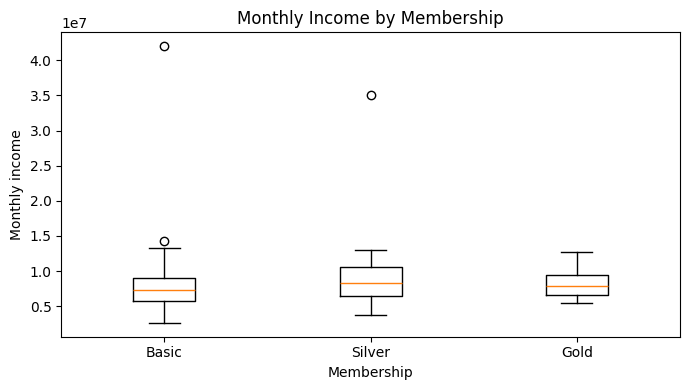

In [19]:

membership_order = ["Basic", "Silver", "Gold"]
groups = [
    df.loc[df["membership"] == level, "monthly_income"].dropna()
    for level in membership_order
]

plt.figure(figsize=(7, 4))
plt.boxplot(groups, tick_labels=membership_order)
plt.xlabel("Membership")
plt.ylabel("Monthly income")
plt.title("Monthly Income by Membership")
plt.tight_layout()
plt.show()


In [20]:

df.groupby("purchased")["spending_score"].agg(
    ["count", "mean", "median", "std"]
)


,count,mean,median,std
purchased,,,,
No,79,59.78,61.00,18.13
Yes,41,63.56,63.00,18.29


## 7.3 Categorical vs categorical

In [21]:

purchase_by_membership = pd.crosstab(
    df["membership"],
    df["purchased"],
    normalize="index"
) * 100

purchase_by_membership.round(1)


purchased,No,Yes
membership,,
Basic,72.60,27.40
Gold,52.60,47.40
Silver,59.50,40.50


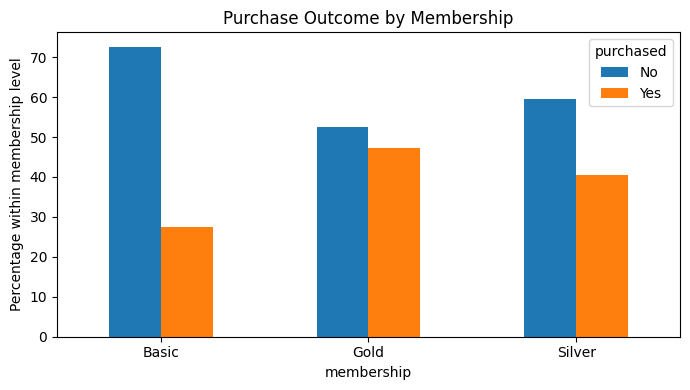

In [22]:

purchase_by_membership.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Percentage within membership level")
plt.title("Purchase Outcome by Membership")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



# 8. Outlier detection

An **outlier** is an observation that is unusually far from most other observations.

Outliers may represent:

- valid extreme cases,
- measurement errors,
- data-entry errors,
- unusual but important events.

Therefore, detecting an outlier does **not** automatically mean it should be deleted.



## 8.1 Boxplots

Boxplots are a useful first visual check.

Values beyond the whiskers are potential outliers under the standard IQR convention.


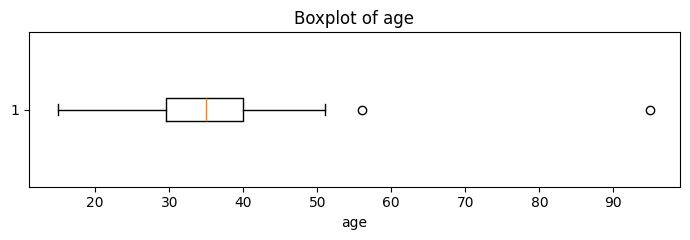

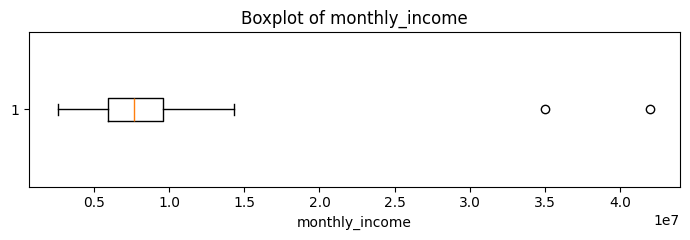

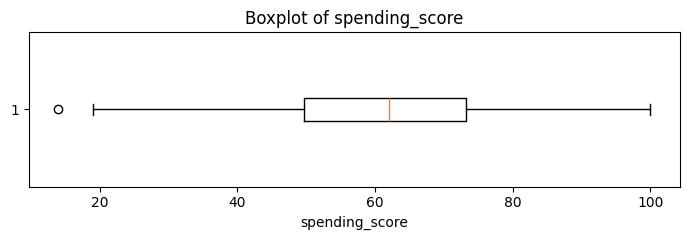

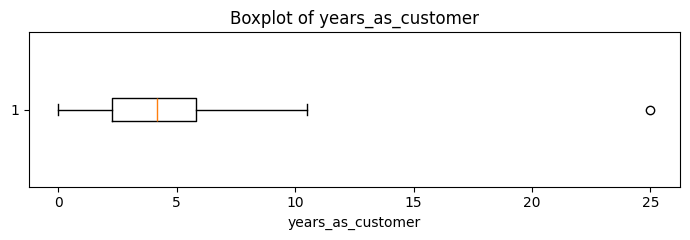

In [23]:

for col in numeric_cols:
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()



## 8.2 IQR method

For a numerical variable:

\[
IQR = Q_3 - Q_1
\]

A common rule marks observations as potential outliers when:

\[
x < Q_1 - 1.5(IQR)
\]

or

\[
x > Q_3 + 1.5(IQR)
\]

This is a screening rule, not a universal definition of an invalid observation.


In [24]:

def detect_iqr_outliers(series):
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (series < lower) | (series > upper)

    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum()
    }

outlier_summary = pd.DataFrame({
    col: detect_iqr_outliers(df[col])
    for col in numeric_cols
}).T

outlier_summary


,q1,q3,iqr,lower_bound,upper_bound,outlier_count
age,29.50,40.00,10.50,13.75,55.75,2.00
monthly_income,"5,968,000.00","9,608,000.00","3,640,000.00","508,000.00","15,068,000.00",2.00
spending_score,49.75,73.25,23.50,14.50,108.50,1.00
years_as_customer,2.27,5.83,3.55,-3.05,11.15,1.00


In [25]:

def get_iqr_outlier_rows(dataframe, column):
    s = dataframe[column]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return dataframe[(s < lower) | (s > upper)]

get_iqr_outlier_rows(df, "monthly_income")


,customer_id,age,monthly_income,spending_score,years_as_customer,gender,city,membership,purchased
10,1011,44.00,"35,000,000.00",53.00,4.00,Male,Jakarta,Silver,No
55,1056,29.00,"42,000,000.00",63.00,4.50,Male,Surabaya,Basic,Yes



## 8.3 Z-score method

Another common approach uses the z-score:

\[
z = \frac{x-\mu}{\sigma}
\]

A common—but not mandatory—screening threshold is:

\[
|z| > 3
\]

The z-score method is more appropriate when the variable is approximately normally distributed. It is sensitive to extreme values because the mean and standard deviation themselves are affected by outliers.


In [26]:

def zscore_outliers(series, threshold=3):
    clean = series.dropna()
    mean = clean.mean()
    std = clean.std()

    z = (series - mean) / std
    return df[z.abs() > threshold]

zscore_outliers(df["monthly_income"])


,customer_id,age,monthly_income,spending_score,years_as_customer,gender,city,membership,purchased
10,1011,44.00,"35,000,000.00",53.00,4.00,Male,Jakarta,Silver,No
55,1056,29.00,"42,000,000.00",63.00,4.50,Male,Surabaya,Basic,Yes



# 9. Data-quality checks beyond missing values and outliers

EDA should also investigate consistency and validity.

Examples:

- duplicate records,
- impossible values,
- inconsistent labels,
- incorrect data types,
- impossible dates,
- duplicated identifiers.


In [27]:

print("Number of completely duplicated rows:", df.duplicated().sum())
print("Duplicated customer IDs:", df["customer_id"].duplicated().sum())

print("\nMinimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

print("\nCity labels:")
print(sorted(df["city"].dropna().unique().astype(str)))

print("\nGender labels:")
print(sorted(df["gender"].dropna().unique().astype(str)))


Number of completely duplicated rows: 0
Duplicated customer IDs: 0

Minimum age: 15.0
Maximum age: 95.0

City labels:
[np.str_('Bandung'), np.str_('Jakarta'), np.str_('Malang'), np.str_('Surabaya'), np.str_('surabaya')]

Gender labels:
[np.str_('Female'), np.str_('Male'), np.str_('female ')]



# 10. Build an EDA summary

At the end of EDA, summarize what was discovered.

A useful EDA summary should distinguish:

1. **observations** — what the data show,
2. **risks** — why the observation may matter, and
3. **actions** — what preprocessing should be considered.


In [28]:

summary = pd.DataFrame([
    {
        "issue": "Missing numerical values",
        "observation": "Age and monthly_income contain missing values.",
        "risk": "Many models cannot directly handle NaN values.",
        "recommended_action": "Consider median imputation after examining distributions."
    },
    {
        "issue": "Missing categorical values",
        "observation": "Gender, city, and membership contain missing values.",
        "risk": "Missing categories can reduce usable observations or create errors.",
        "recommended_action": "Consider mode imputation or an explicit 'Unknown' category."
    },
    {
        "issue": "Inconsistent labels",
        "observation": "Examples include 'Surabaya' vs 'surabaya' and 'Female' vs 'female '.",
        "risk": "Equivalent categories may be treated as different groups.",
        "recommended_action": "Strip whitespace and standardize capitalization."
    },
    {
        "issue": "Potential outliers",
        "observation": "Some age, income, and customer-tenure values are extreme.",
        "risk": "Outliers may distort averages, scaling, and model fitting.",
        "recommended_action": "Validate against source data before removing, capping, or transforming."
    },
    {
        "issue": "Identifier field",
        "observation": "customer_id uniquely identifies customers.",
        "risk": "It usually provides no predictive meaning and may introduce noise.",
        "recommended_action": "Exclude from most model feature sets unless it has a meaningful role."
    },
])

summary


,issue,observation,risk,recommended_action
0,Missing numerical values,Age and monthly_income contain missing values.,Many models cannot directly handle NaN values.,Consider median imputation after examining dis...
1,Missing categorical values,"Gender, city, and membership contain missing v...",Missing categories can reduce usable observati...,Consider mode imputation or an explicit 'Unkno...
2,Inconsistent labels,Examples include 'Surabaya' vs 'surabaya' and ...,Equivalent categories may be treated as differ...,Strip whitespace and standardize capitalization.
3,Potential outliers,"Some age, income, and customer-tenure values a...","Outliers may distort averages, scaling, and mo...","Validate against source data before removing, ..."
4,Identifier field,customer_id uniquely identifies customers.,It usually provides no predictive meaning and ...,Exclude from most model feature sets unless it...



# 11. Recommended preprocessing

Based on the EDA above, a reasonable preprocessing plan would be:

### Step 1 — Standardize categorical text

- remove leading/trailing spaces,
- standardize capitalization,
- merge equivalent labels.

### Step 2 — Handle missing values

For example:

- numerical features → median imputation,
- categorical features → most frequent value or `"Unknown"`.

### Step 3 — Investigate outliers

Do not remove outliers automatically.

First determine whether they are:

- data-entry errors,
- measurement errors,
- or valid extreme observations.

Possible treatments include:

- correction,
- removal,
- winsorization/capping,
- logarithmic transformation,
- robust scaling,
- or retaining them unchanged.

### Step 4 — Encode categorical variables

Typical choices:

- **One-hot encoding** for nominal features such as `city` and `gender`,
- **Ordinal encoding** for ordered features such as `membership`.

### Step 5 — Scale numerical features when required

Scaling is often useful for algorithms such as:

- K-nearest neighbors,
- support vector machines,
- neural networks,
- logistic regression with regularization,
- clustering.

Tree-based methods usually do not require feature scaling.

### Step 6 — Remove identifiers from model features

`customer_id` should normally remain available for traceability but not be used as a predictive feature.



# 12. Example preprocessing implementation

The following code demonstrates one possible implementation.

This is **not** the only correct preprocessing strategy. The correct decisions depend on the dataset, domain, and modeling objective.


In [29]:

clean_df = df.copy()

# 1. Standardize text categories
for col in ["gender", "city", "membership", "purchased"]:
    clean_df[col] = clean_df[col].str.strip().str.title()

# 2. Impute numerical missing values using median
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# 3. Impute categorical missing values using the mode
for col in categorical_cols:
    if clean_df[col].isna().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

print("Remaining missing values:", clean_df.isna().sum().sum())

clean_df.head()


Remaining missing values: 0


,customer_id,age,monthly_income,spending_score,years_as_customer,gender,city,membership,purchased
0,1001,38.00,"5,441,000.00",44.00,3.60,Female,Jakarta,Basic,No
1,1002,25.00,"8,448,000.00",58.00,5.00,Female,Surabaya,Basic,No
2,1003,43.00,"8,550,000.00",28.00,6.50,Female,Bandung,Basic,No
3,1004,95.00,"11,398,000.00",34.00,1.40,Female,Malang,Basic,No
4,1005,15.00,"10,088,000.00",98.00,3.70,Female,Malang,Silver,No


In [30]:

# Optional: cap selected numerical variables using IQR boundaries

def iqr_cap(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return series.clip(lower=lower, upper=upper)

# Example only:
# clean_df["monthly_income"] = iqr_cap(clean_df["monthly_income"])


In [31]:

# One-hot encode nominal categorical variables

model_df = pd.get_dummies(
    clean_df.drop(columns=["customer_id"]),
    columns=["gender", "city"],
    drop_first=False,
    dtype=int
)

# Ordinal mapping for membership
membership_map = {
    "Basic": 1,
    "Silver": 2,
    "Gold": 3
}

model_df["membership"] = model_df["membership"].map(membership_map)

# Binary target encoding
model_df["purchased"] = model_df["purchased"].map({
    "No": 0,
    "Yes": 1
})

model_df.head()


,age,monthly_income,spending_score,years_as_customer,membership,purchased,gender_Female,gender_Male,city_Bandung,city_Jakarta,city_Malang,city_Surabaya
0,38.00,"5,441,000.00",44.00,3.60,1,0,1,0,0,1,0,0
1,25.00,"8,448,000.00",58.00,5.00,1,0,1,0,0,0,0,1
2,43.00,"8,550,000.00",28.00,6.50,1,0,1,0,1,0,0,0
3,95.00,"11,398,000.00",34.00,1.40,1,0,1,0,0,0,1,0
4,15.00,"10,088,000.00",98.00,3.70,2,0,1,0,0,0,1,0



# 13. Final EDA checklist

Before moving to modeling, ask:

- [ ] Do I understand what each row represents?
- [ ] Do I understand what each variable represents?
- [ ] Are the data types correct?
- [ ] Which variables are numerical?
- [ ] Which variables are categorical?
- [ ] Are category labels consistent?
- [ ] Are there missing values?
- [ ] Have I measured missing-value percentages?
- [ ] Are there duplicate rows or duplicate identifiers?
- [ ] Are there impossible or suspicious values?
- [ ] Are there potential outliers?
- [ ] Have I analyzed important variable relationships?
- [ ] Have I checked for strong correlations or redundancy?
- [ ] Have I considered class imbalance in the target?
- [ ] Can every preprocessing decision be justified?

---

## Key idea

**EDA is not just about plotting graphs.**

Its purpose is to understand:

> **What is in the data, what might be wrong with it, what relationships exist, and what should be done before statistical analysis or machine learning.**



# 14. Student exercises

Use the same dataset to answer the following questions.

### Exercise 1 — Data types

Create a table showing:

- column name,
- pandas data type,
- analytical type,
- number of unique values.

### Exercise 2 — Missing data

Which variable has the largest percentage of missing values?

Would you remove the column or impute the values? Explain why.

### Exercise 3 — Categorical quality

Find all inconsistent category labels and propose a cleaning rule.

### Exercise 4 — Bivariate analysis

Investigate the relationship between:

1. `age` and `spending_score`,
2. `membership` and `spending_score`,
3. `city` and `purchased`.

Choose an appropriate table or visualization for each pair.

### Exercise 5 — Outliers

Use the IQR method to identify potential outliers in `age` and `years_as_customer`.

For each outlier, explain whether you would:

- keep it,
- verify it,
- cap it,
- transform it, or
- remove it.

### Exercise 6 — Preprocessing recommendation

Write a short preprocessing plan for this dataset before training a classification model to predict `purchased`.



# 15. Optional extension: reusable EDA helper

For larger datasets, we can automate basic profiling while still interpreting the results manually.


In [32]:

def basic_eda_report(data):
    report = pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "non_null": data.notna().sum(),
        "missing": data.isna().sum(),
        "missing_pct": (data.isna().mean() * 100).round(2),
        "unique": data.nunique(dropna=True)
    })

    return report

basic_eda_report(df)


,dtype,non_null,missing,missing_pct,unique
customer_id,int64,120,0,0.00,120
age,float64,115,5,4.17,35
monthly_income,float64,113,7,5.83,112
spending_score,float64,120,0,0.00,57
years_as_customer,float64,120,0,0.00,65
gender,object,117,3,2.50,3
city,object,116,4,3.33,5
membership,object,118,2,1.67,3
purchased,object,120,0,0.00,2
